In [79]:
import numpy as np
import pyat.readwrite as at
import scipy.io
import matplotlib.pyplot as plt
import scipy.signal as sp

In [80]:
%reload_ext pyat.readwrite

In [81]:
# [Title, Freq, ssp, bdry, pos, beam, cint, rmax] = at.read_env("feif_scenario.env", "KRAKEN")

In [243]:
SAMPLING_FREQ = 2000
TRUE_SOUNDSPEED = 1460

FREQ_RANGE = [200, 350]

In [244]:
data1 = scipy.io.loadmat("../acoustic_inversion/scripts/mode_arrival_times_rts.mat")
replicas = scipy.io.loadmat("field_values20260707/field_values20260707.mat")
data1['mode_nos'] = data1['mode_nos'] - 1

f = replicas['f'].squeeze()
f_Vg = f[1:-1]
c = replicas['soundspeed'].squeeze()
Vg = replicas['Vg'].squeeze()
Vg = Vg[data1['mode_nos'].squeeze()]
receiver_range = replicas['range'][0,0]*1e3

t0 = receiver_range/1500


In [245]:
data1['peaks_coordinates'] = [ M for M in data1['peaks_coordinates'][0]]

In [247]:
f_mask = np.array([f_Vg >= FREQ_RANGE[0],f_Vg <= FREQ_RANGE[1]]).all(0)
regression_f = f_Vg[f_mask]

In [248]:
coefs = np.array([np.polyfit(d[:,1], d[:,0], 2) for d in data1['peaks_coordinates']])
arrival_times_data = np.array([np.polyval(c, regression_f) for c in coefs])

In [249]:
#arrival_times_data = receiver_range/Vg[:, c == TRUE_SOUNDSPEED, ...]
arrival_times_replica = -t0 + receiver_range/Vg[...,f_mask].transpose([1,0,2])

In [250]:
nspeed, nmodes, nfreq = arrival_times_replica.shape

Text(0, 0.5, 'Frequency (Hz)')

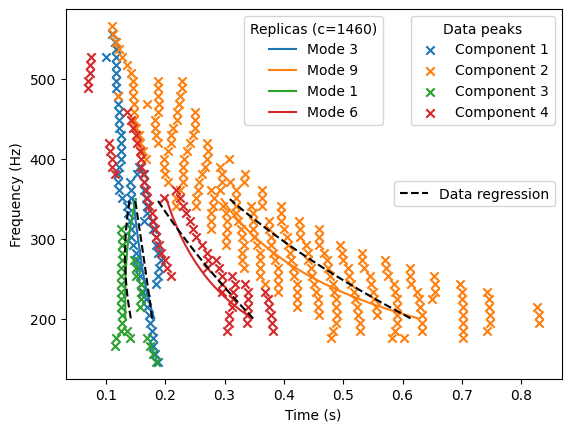

In [292]:
fig, ax = plt.subplots()

for ind, p in enumerate(data1['peaks_coordinates']):
    ax.scatter(p[:,0], p[:,1], marker='x', label=f'Component {ind + 1}')
    
rep = ax.plot(arrival_times_replica[c==TRUE_SOUNDSPEED, :, :].squeeze().T, regression_f)
ax.set_prop_cycle(None)
dat = ax.plot(arrival_times_data.T, regression_f, ls='--', c='k')

legend1 = ax.legend(title="Data peaks")
ax.add_artist(legend1)

legend2 = ax.legend(rep, [f'Mode {m+1}' for m in data1['mode_nos'][0]], title="Replicas (c=1460)", loc="upper center")
ax.add_artist(legend2)

ax.legend([dat[0]], ['Data regression'], loc="center right")

ax.set_xlabel("Time (s)")
ax.set_ylabel("Frequency (Hz)")

In [293]:
fig.savefig("arrival_times_components.png", dpi=600)

## Direct dispersion

In [252]:
residuals_direct = arrival_times_data - arrival_times_replica

In [253]:
likelihood_direct = np.exp(-np.sum(np.linalg.norm(residuals_direct, 2,2)**2,1))

Text(0, 0.5, 'Likelihood')

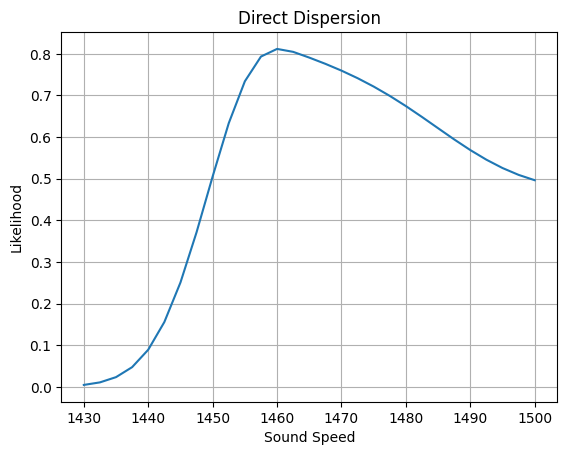

In [254]:
fig, ax = plt.subplots()

ax.plot(c, likelihood_direct)
ax.grid()

ax.set_title(f'Direct Dispersion')
ax.set_xlabel('Sound Speed')
ax.set_ylabel('Likelihood')

In [255]:
fig.savefig('Direct Dispersion Spectrogram.png', dpi=600)

## Intramodal dispersion

In [256]:
def calculate_deltas(x):
    #if x.ndim == 2:
    #    x = x[np.newaxis,...]
        
    delta = np.zeros(x.shape[:-1] + (x.shape[-1], x.shape[-1]))

    for ind in np.ndindex(x.shape[:-2]):
        for indx, m in enumerate(x[ind]):
            delta[ind+(indx,)] = m - m[:,np.newaxis]

    return delta

In [257]:
delta_replica_intramodal = calculate_deltas(arrival_times_replica)
delta_data_intramodal = calculate_deltas(arrival_times_data)

residual_intramodal = np.abs(delta_replica_intramodal - delta_data_intramodal)**2

likelihood_intramodal = np.exp(-np.linalg.norm(residual_intramodal,2,1))

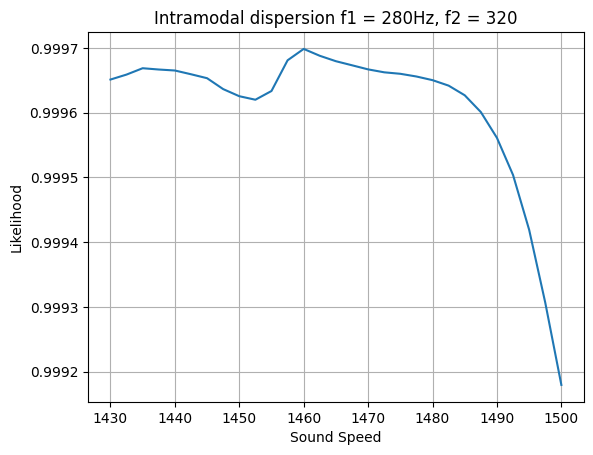

In [258]:
fig, ax = plt.subplots()

ax.plot(c, likelihood_intramodal[:,regression_f==280, regression_f==320])

ax.set_title(f'Intramodal dispersion f1 = 280Hz, f2 = 320')
ax.set_xlabel('Sound Speed')
ax.set_ylabel('Likelihood')

ax.grid()

In [259]:
fig.savefig('Intramodal Dispersion Spectrogram.png', dpi=600)

## Intermodal dispersion

In [260]:
delta_replica_intermodal = calculate_deltas(arrival_times_replica.mT)
delta_data_intermodal = calculate_deltas(arrival_times_data.mT)

residual_intermodal = np.abs(delta_replica_intermodal - delta_data_intermodal)**2

likelihood_intermodal = np.exp(-np.linalg.norm(residual_intermodal,2,1))

Text(0.02, 0.5, 'Likelihood ($\\exp (-e_2/\\sigma)$)')

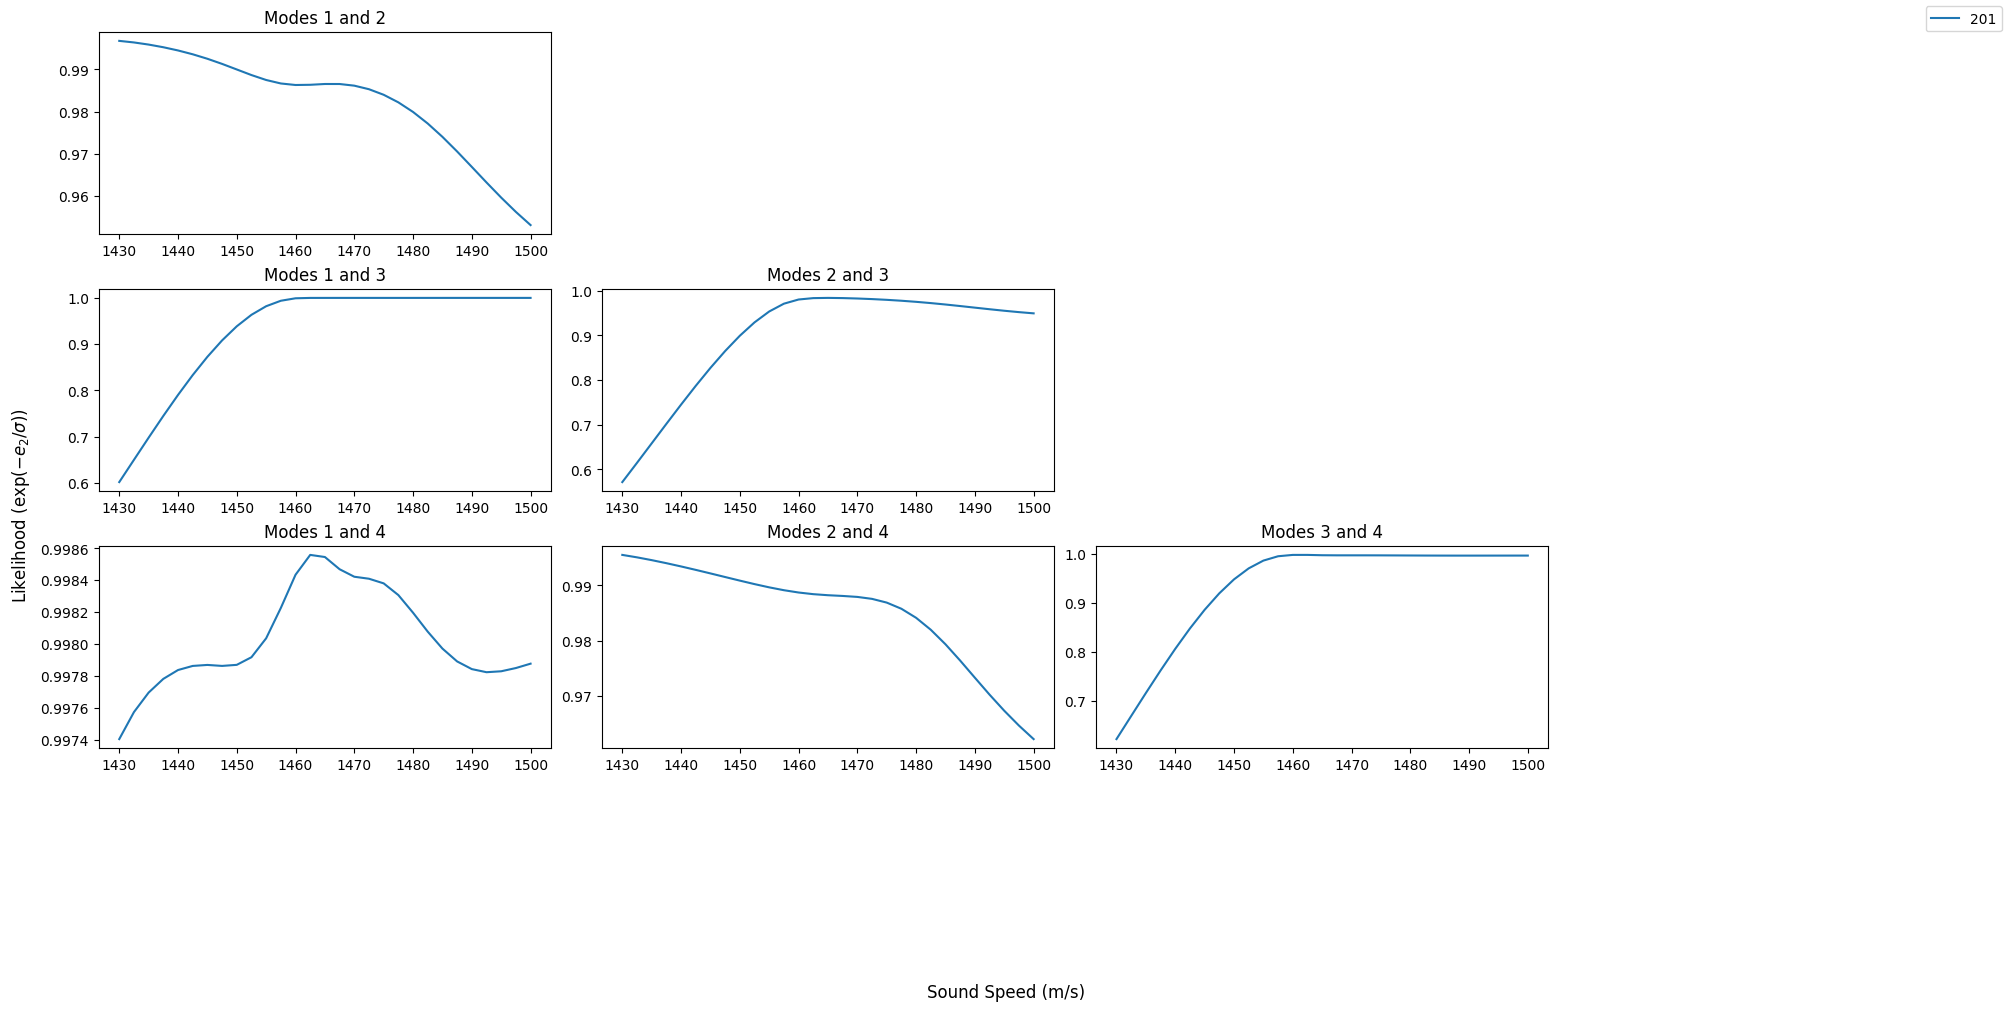

In [261]:
fig = plt.figure(layout='constrained')

for ir in range(3):
    for ic in range(ir+1):
        ax = fig.add_subplot(4,4, 4*ir + ic +1)
        l1 = ax.plot(c, likelihood_intermodal[:, ir+1, ic])

        ax.set_title(f'Modes {ic+1} and {ir+2}')

fig.legend(l1, regression_f[::20])
fig.set_size_inches([20,10])
fig.supxlabel('Sound Speed (m/s)')
fig.supylabel('Likelihood ($\\exp (-e_2/\\sigma)$)')

In [262]:
residual_sum = np.tril(residual_intermodal).sum(tuple(range(1,4))) + np.tril(residual_intramodal).sum(tuple(range(1,4)))

Text(0, 0.5, 'Likelihood')

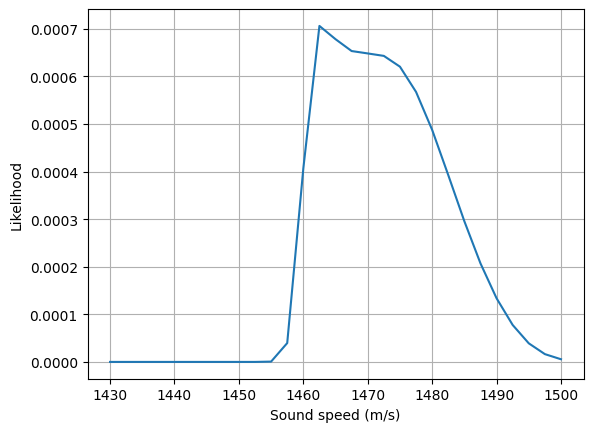

In [290]:
fig, ax = plt.subplots()

ax.plot(c, np.exp(-residual_sum))
ax.grid()

ax.set_xlabel("Sound speed (m/s)")
ax.set_ylabel("Likelihood")

In [291]:
fig.savefig("likelihood_combined.png", dpi=600)

In [237]:
calculate_deltas(arrival_times_replica.transpose([1,0,2]))

array([[[[ 0.00000000e+00, -2.84591215e-04, -5.69182431e-04, ...,
          -1.52730619e-02, -1.53679256e-02, -1.54627894e-02],
         [ 2.84591215e-04,  0.00000000e+00, -2.84591215e-04, ...,
          -1.49884707e-02, -1.50833344e-02, -1.51781982e-02],
         [ 5.69182431e-04,  2.84591215e-04,  0.00000000e+00, ...,
          -1.47038795e-02, -1.47987432e-02, -1.48936069e-02],
         ...,
         [ 1.52730619e-02,  1.49884707e-02,  1.47038795e-02, ...,
           0.00000000e+00, -9.48637385e-05, -1.89727477e-04],
         [ 1.53679256e-02,  1.50833344e-02,  1.47987432e-02, ...,
           9.48637385e-05,  0.00000000e+00, -9.48637385e-05],
         [ 1.54627894e-02,  1.51781982e-02,  1.48936069e-02, ...,
           1.89727477e-04,  9.48637385e-05,  0.00000000e+00]],

        [[ 0.00000000e+00, -3.79454954e-04, -6.64046169e-04, ...,
          -1.61268355e-02, -1.62216993e-02, -1.62216993e-02],
         [ 3.79454954e-04,  0.00000000e+00, -2.84591215e-04, ...,
          -1.57473806e